Importing the Libraries

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

Understanding Data

In [ ]:
df = pd.read_csv('cs-training.csv', index_col=0)

# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# Check missing values & duplicates
print(f'Missing value =\n{df.isnull().sum()}')
print(f'\nDuplicated = {df.duplicated().sum()}')

Missing value =
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Duplicated = 609


In [ ]:
# Show shape
df.shape

(150000, 11)

In [ ]:
# Columns name
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [ ]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

Data Handling & EDA

In [ ]:
# Show sample records
df.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


In [ ]:
# Show NULL value percentages
data_null = round(df.isna().sum() / df.shape[0] * 100, 2)
data_null.to_frame(name='percent NULL data (%)')

,percent NULL data (%)
SeriousDlqin2yrs,0.00
RevolvingUtilizationOfUnsecuredLines,0.00
age,0.00
NumberOfTime30-59DaysPastDueNotWorse,0.00
DebtRatio,0.00
MonthlyIncome,19.82
NumberOfOpenCreditLinesAndLoans,0.00
NumberOfTimes90DaysLate,0.00
NumberRealEstateLoansOrLines,0.00
NumberOfTime60-89DaysPastDueNotWorse,0.00


In [ ]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [ ]:
# Impute missing values before plotting/modeling
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0], inplace=True)

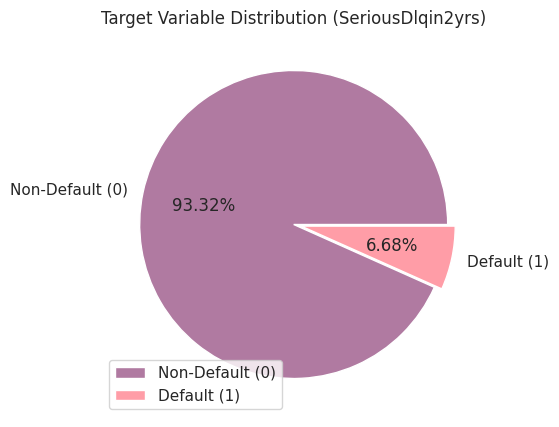

In [ ]:
# Target Column Analysis
target = "SeriousDlqin2yrs"
consistent_colors = ['#B07AA1', '#FF9DA7']

plt.figure(figsize=(8, 5))
explode = (0, 0.05)
plt.pie(
    df[target].value_counts().values,
    labels=['Non-Default (0)', 'Default (1)'],
    colors=consistent_colors,
    explode=explode,
    autopct="%1.2f%%"
)
plt.title('Target Variable Distribution (SeriousDlqin2yrs)')
plt.legend()
plt.show()

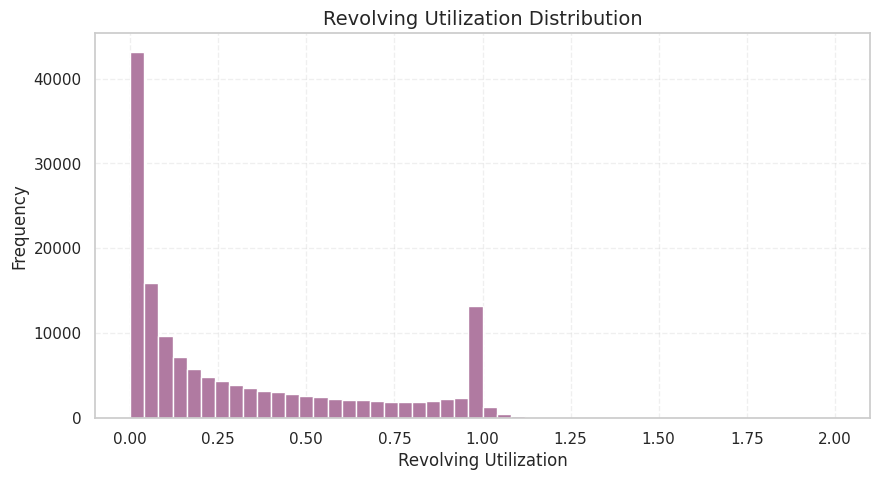

In [ ]:
# Distribution for CIBIL / Utilization score
plt.figure(figsize=(10, 5))
plt.hist(df['RevolvingUtilizationOfUnsecuredLines'], bins=50, color='#B07AA1', edgecolor='white', range=(0, 2))
plt.title('Revolving Utilization Distribution', fontsize=14)
plt.xlabel('Revolving Utilization')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

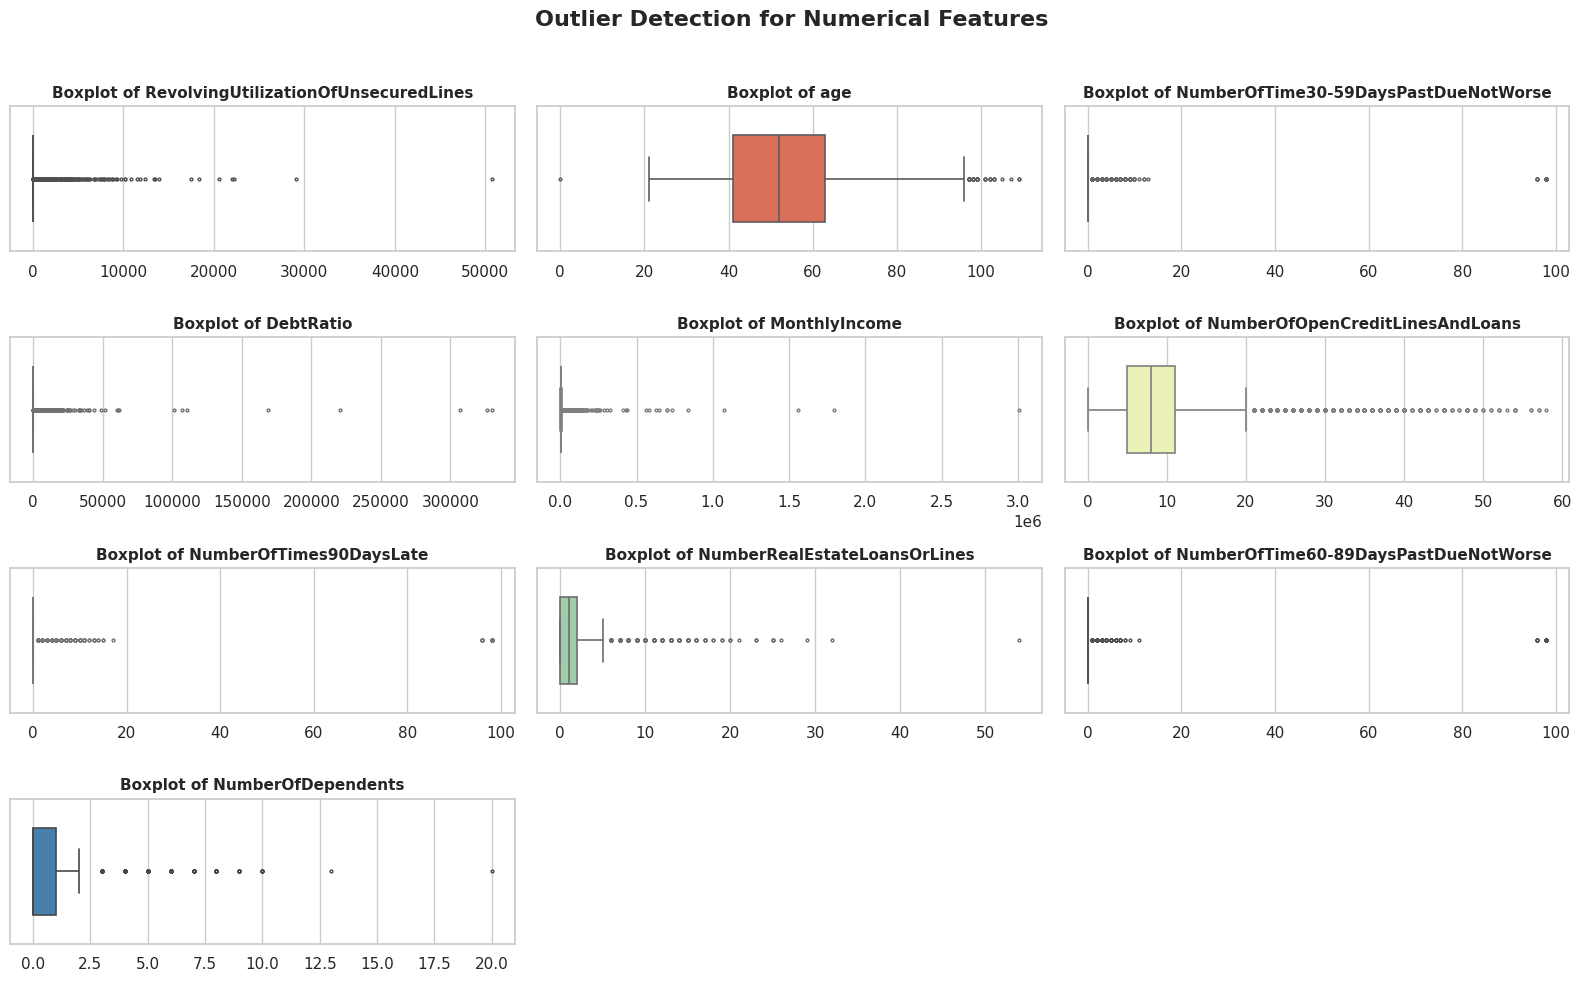

In [ ]:
# Outlier Detection for Numerical Features
numerical = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents'
]

palette = sns.color_palette("Spectral", len(numerical))

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[col], color=palette[i-1], width=0.6, fliersize=2, linewidth=1.2)
    plt.title(f"Boxplot of {col}", fontsize=11, fontweight="bold")
    plt.xlabel("")
plt.suptitle("Outlier Detection for Numerical Features", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Relation between Target column with Numerical columns

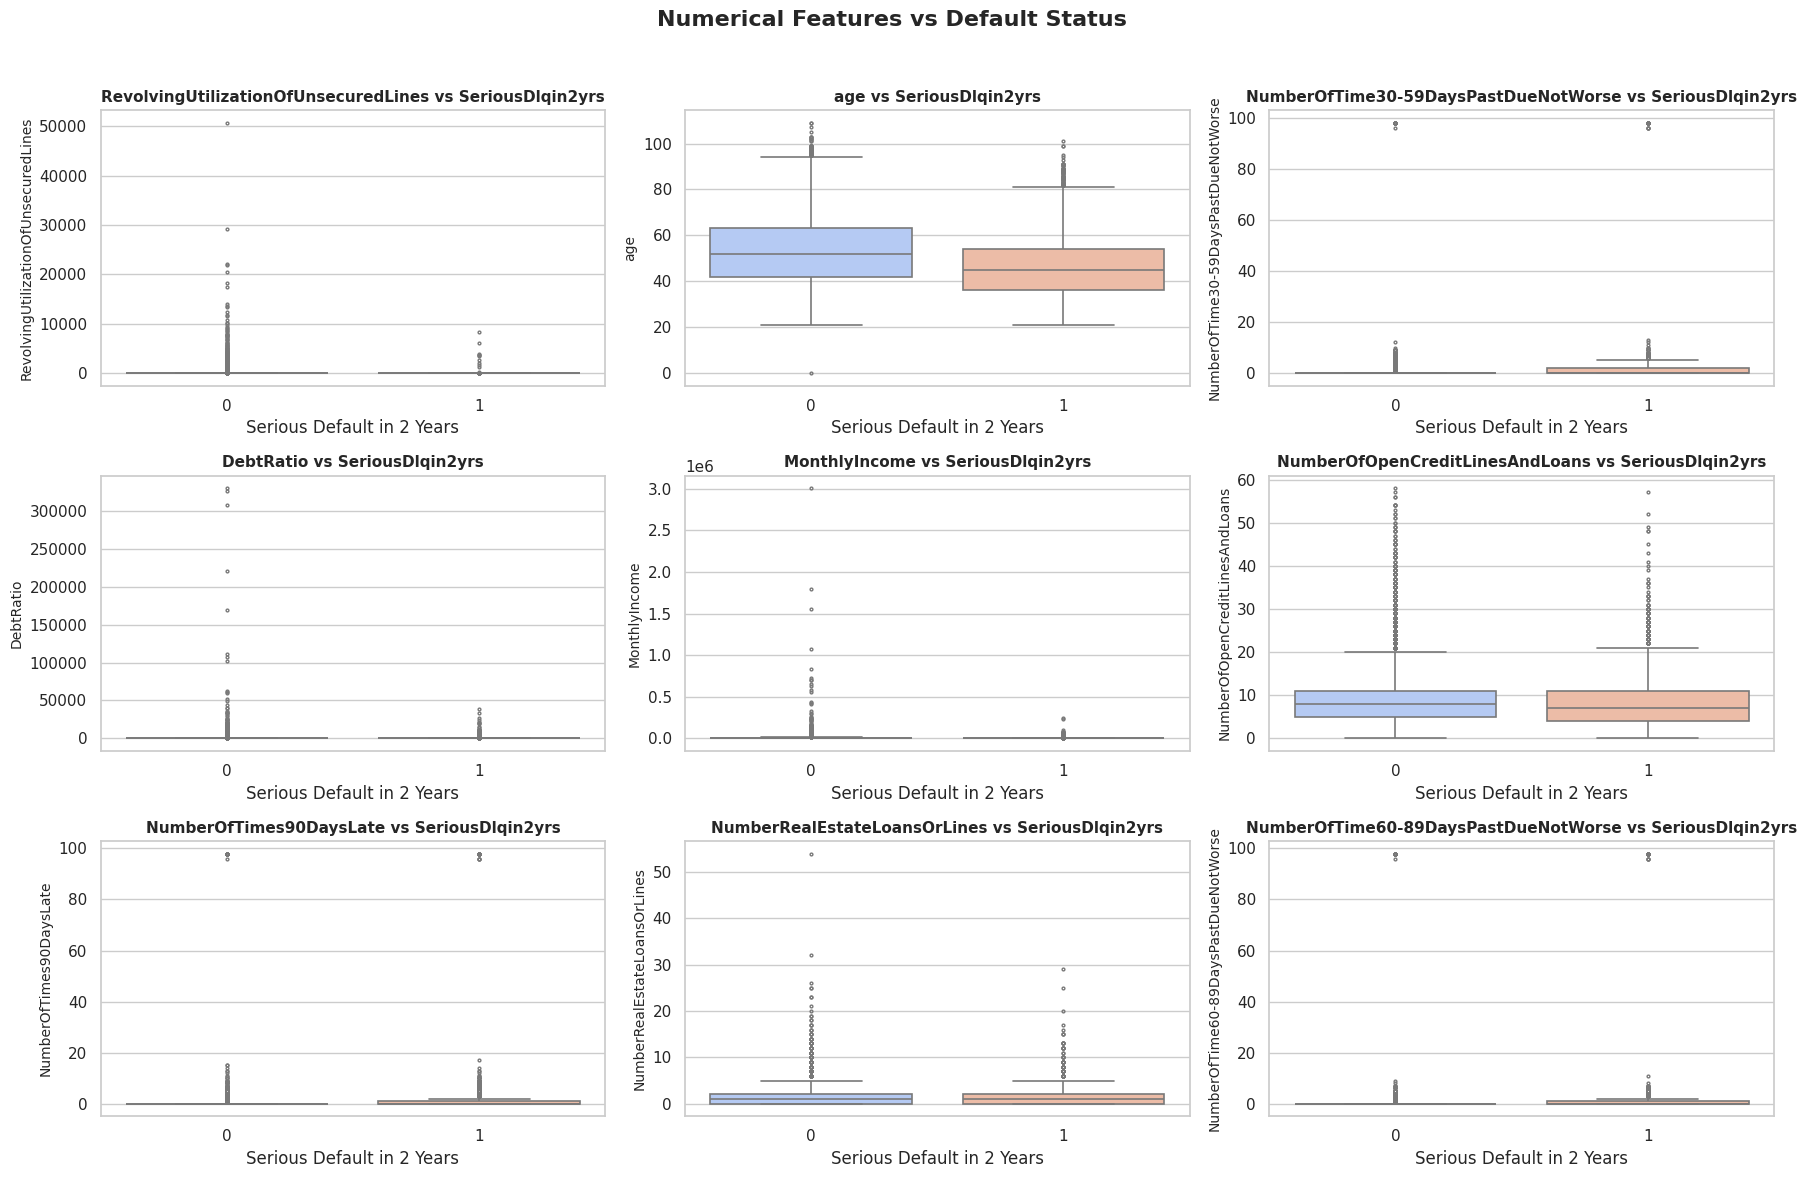

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical[:9]):
    sns.boxplot(
        data=df, x=target, y=col, ax=axes[i], palette="coolwarm", fliersize=2, linewidth=1.2
    )
    axes[i].set_title(f"{col} vs {target}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Serious Default in 2 Years")
    axes[i].set_ylabel(col, fontsize=10)

plt.suptitle("Numerical Features vs Default Status", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Outliers Processor

In [ ]:
# Outlier Capping (IQR Method)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)
    return df

num_cols = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines', 'NumberOfDependents'
]

for col in num_cols:
    df = remove_outliers_iqr(df, col)

Split Data to Train & Test

In [ ]:
X = df.drop(columns=[target])
y = df[target]

# Train-test split (80% Train, 20% Test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120000, 10)
Test shape: (30000, 10)


Model Training & Evaluation

Logistic Regression Model

In [ ]:
# Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=['Non-Default (0)', 'Default (1)']))

=== Logistic Regression ===
Accuracy: 0.7607666666666667
                 precision    recall  f1-score   support

Non-Default (0)       0.98      0.76      0.86     27995
    Default (1)       0.18      0.75      0.29      2005

       accuracy                           0.76     30000
      macro avg       0.58      0.75      0.58     30000
   weighted avg       0.92      0.76      0.82     30000



Decision Tree Model

In [ ]:
# Decision Tree Model
tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree, target_names=['Non-Default (0)', 'Default (1)']))

=== Decision Tree ===
Accuracy: 0.7842666666666667
                 precision    recall  f1-score   support

Non-Default (0)       0.98      0.78      0.87     27995
    Default (1)       0.21      0.77      0.32      2005

       accuracy                           0.78     30000
      macro avg       0.59      0.78      0.60     30000
   weighted avg       0.93      0.78      0.84     30000



Random Forest Model

In [ ]:
# Random Forest Model
rf = RandomForestClassifier(n_estimators=150, max_depth=12, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=['Non-Default (0)', 'Default (1)']))

=== Random Forest ===
Accuracy: 0.8505
                 precision    recall  f1-score   support

Non-Default (0)       0.97      0.86      0.92     27995
    Default (1)       0.26      0.66      0.37      2005

       accuracy                           0.85     30000
      macro avg       0.62      0.76      0.64     30000
   weighted avg       0.93      0.85      0.88     30000

